In [ ]:
import numpy as np
import tensorflow as tf

path_to_file = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)

text = open(path_to_file, 'rb').read().decode(encoding='utf-8')
print(f'Length of text: {len(text)} characters')

vocab = sorted(list(set(text)))
vocab_size = len(vocab)
print(f'Unique characters (Vocab size): {vocab_size}')

char2idx = {u: i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)

text_as_int = np.array([char2idx[c] for c in text])

seq_length = 50
examples_per_epoch = len(text) // (seq_length + 1)

char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

BATCH_SIZE = 64
BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)
print("Data preprocessing complete. Dataset is ready.")

Length of text: 1115394 characters
Unique characters (Vocab size): 65
Data preprocessing complete. Dataset is ready.


In [ ]:
import math
import tensorflow as tf
import numpy as np

DATASET_SIZE = tf.data.experimental.cardinality(dataset).numpy()
if DATASET_SIZE < 0:
    DATASET_SIZE = len(list(dataset))

train_size = int(0.6 * DATASET_SIZE)
val_size = int(0.2 * DATASET_SIZE)
test_size = DATASET_SIZE - train_size - val_size

train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size).take(val_size)
test_dataset = dataset.skip(train_size + val_size)

print(f"Total batches: {DATASET_SIZE}")
print(f"Training batches: {train_size}")
print(f"Validation b
atches: {val_size}")
print(f"Test batches: {test_size}")

Total batches: 341
Training batches: 204
Validation batches: 68
Test batches: 69


In [ ]:
import numpy as np
import tensorflow as tf

embedding_dim = 256
rnn_units = 512

def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(batch_shape=[batch_size, None]),
        tf.keras.layers.Embedding(
            vocab_size,
            embedding_dim
        ),
        tf.keras.layers.SimpleRNN(
            rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer='glorot_uniform'
        ),
        tf.keras.layers.Dense(vocab_size)
    ])
    return model

model = build_model(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    batch_size=BATCH_SIZE
)

model.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_31 (Embedding)        │ (64, None, 256)        │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_31 (SimpleRNN)       │ (64, None, 512)        │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (64, None, 65)         │        33,345 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 443,713 (1.69 MB)

 Trainable params: 443,713 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2660 - loss: 2.7824
--- Generated text at the end of Epoch 1 ---
ROMEO: GQ3zYOLSSXVQXVONR$XVQUXQLZAPTQFV$ARD&UCVRTIOVZXXVQGCXOVKZZX&VBQ&&ZQUVXXVV3DZZPPQQMETC&ZJQQK$J&$cQXVCVPJUVWJXQVIVGUXEXVUCVISGCHQCKQQGXGLOZPFQUMKCVGRGVPYZjQZQQVXO$KZXPRTPPQ$VXVVKQVVWCVON;3JMQZRDYBEXVYCX
--------------------------------------------------
204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.3334 - loss: 2.4069 - val_accuracy: 0.3976 - val_loss: 2.0704
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4173 - loss: 2.0153
--- Generated text at the end of Epoch 2 ---
ROMEO: hexven thy woman.

Seat your hast the sentess to the rrigans to whombers. Theit not in this not to have your sonars, the vallinge to your wask'd that thou arterter, canqune,
And more growncag the weal
--------------------------------------------------
204/204 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.4289 - loss: 1.9681 - val_accuracy: 0.4471

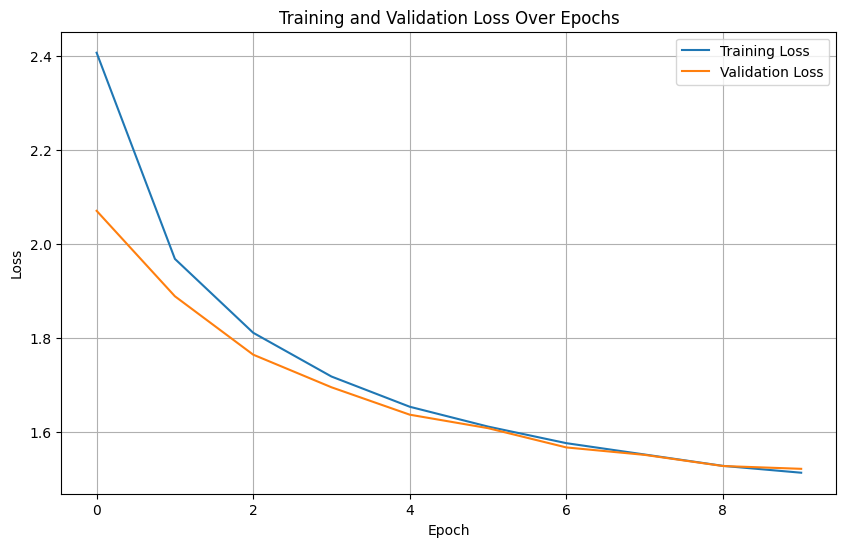

In [ ]:
\\\\\\import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

vocab = sorted(list(set(text)))
char2idx = {u: i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)

def generate_text(model, start_string, num_generate=200):
    gen_model = build_model(vocab_size, embedding_dim, rnn_units, batch_size=1)
    gen_model.set_weights(model.get_weights())
    for layer in gen_model.layers:
        if hasattr(layer, 'reset_states') and callable(layer.reset_states):
            layer.reset_states()

    input_eval = [char2idx[s] for s in start_string]
    input_eval = tf.expand_dims(input_eval, 0)

    text_generated = []
    temperature = 0.7

    for i in range(num_generate):
        predictions = gen_model(input_eval)
        predictions = tf.squeeze(predictions, 0)
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()
        input_eval = tf.expand_dims([predicted_id], 0)
        text_generated.append(idx2char[predicted_id])

    return start_string + ''.join(text_generated)

class TextGenerationCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"\n--- Generated text at the end of Epoch {epoch + 1} ---")
        print(generate_text(self.model, start_string="ROMEO: "))
        print("-" * 50)

def plot_history(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)

vocab_size = len(vocab)
embedding_dim = 256
rnn_units = 512
BATCH_SIZE = 64

model = build_model(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    batch_size=BATCH_SIZE
)

model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])

EPOCHS = 10

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[TextGenerationCallback()]
)

plot_history(history)

In [ ]:
print("Average loss per epoch:")
for i, loss_value in enumerate(history.history['loss']):
    print(f"Epoch {i+1}: {loss_value:.4f}")

print("\nEvaluation")
eval_loss, eval_accuracy = model.evaluate(test_dataset, batch_size=BATCH_SIZE)

Average loss per epoch:
Epoch 1: 2.4069
Epoch 2: 1.9681
Epoch 3: 1.8109
Epoch 4: 1.7178
Epoch 5: 1.6535
Epoch 6: 1.6113
Epoch 7: 1.5760
Epoch 8: 1.5519
Epoch 9: 1.5277
Epoch 10: 1.5131

Evaluation
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5470 - loss: 1.5115


1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step


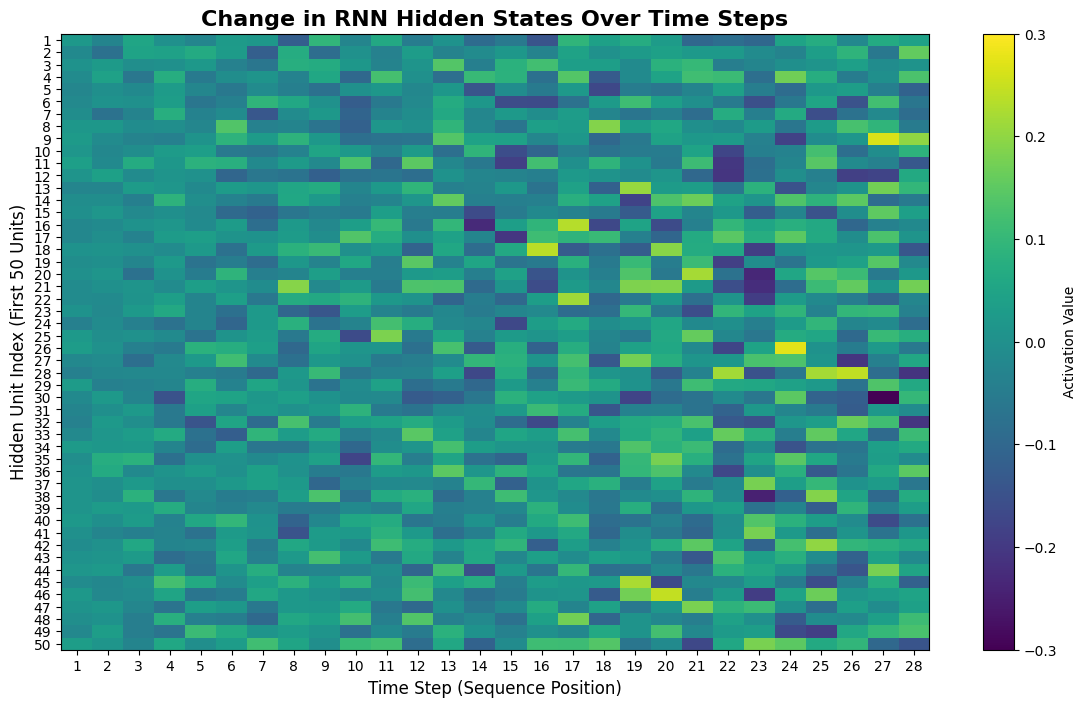

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


path_to_file = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)
text = open(path_to_file, 'rb').read().decode(encoding='utf-8')

vocab = sorted(list(set(text)))
vocab_size = len(vocab)
char2idx = {u: i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)
text_as_int = np.array([char2idx[c] for c in text])

seq_length = 50
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)
sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

BATCH_SIZE = 64
BUFFER_SIZE = 10000
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

embedding_dim = 256
rnn_units = 512

def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(batch_shape=[batch_size, None]),
        tf.keras.layers.Embedding(
            vocab_size,
            embedding_dim
        ),
        tf.keras.layers.SimpleRNN(
            rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer='glorot_uniform'
        ),
        tf.keras.layers.Dense(vocab_size)
    ])
    return model

model = build_model(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    batch_size=BATCH_SIZE
)



inference_model = build_model(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    batch_size=1
)

if model.built:
    inference_model.set_weights(model.get_weights())

rnn_layer_extractor = tf.keras.Model(
    inputs=inference_model.inputs,
    outputs=inference_model.layers[1].output
)

for layer in inference_model.layers:
    if hasattr(layer, 'reset_states') and callable(layer.reset_states):
        layer.reset_states()

for input_example_batch, target_example_batch in dataset.take(1):
    sample_sequence = input_example_batch[0:1, :28]
    break

hidden_states = rnn_layer_extractor.predict(sample_sequence)

state_matrix = hidden_states[0, :, :50].T

plt.figure(figsize=(14, 8))
plt.imshow(state_matrix, aspect='auto', cmap='viridis', vmin=-0.3, vmax=0.3)

plt.colorbar(label='Activation Value')
plt.title('Change in RNN Hidden States Over Time Steps', fontsize=16, fontweight='bold')
plt.xlabel('Time Step (Sequence Position)', fontsize=12)
plt.ylabel('Hidden Unit Index (First 50 Units)', fontsize=12)

plt.xticks(np.arange(0, state_matrix.shape[1]), labels=np.arange(1, state_matrix.shape[1] + 1))
plt.yticks(np.arange(0, state_matrix.shape[0]), labels=np.arange(1, state_matrix.shape[0] + 1))

plt.show()